In [1]:
#Predicting Movie Success Using Machine Learning
#This project aims to develop a machine learning model to classify movies as **Hit, Average, or Flop** based on various movie-related attributes.
#The project includes data cleaning, exploratory data analysis, feature engineering, model building, model comparison, evaluation,and interpretation of the factors influencing movie success.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#Load Dataset

In [27]:
df = pd.read_csv("movie_metadata.csv")

In [28]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [29]:
#Understanding the Dataset

In [30]:
df.shape

(5043, 28)

In [31]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='str')>

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   str    
 1   director_name              4939 non-null   str    
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   str    
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   str    
 10  actor_1_name               5036 non-null   str    
 11  movie_title                5043 non-null   str    
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64  
 14  act

In [33]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


Data Cleaning & Data Quality Assessment

In [34]:
df.isnull().sum()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

In [35]:
#Checking Duplicate Records
df.duplicated().sum()

np.int64(45)

In [36]:
#Handling Duplicate Records
df.drop_duplicates(inplace=True)

In [37]:
#verifying duplicate removal
df.duplicated().sum()

np.int64(0)

In [38]:
df.shape

(4998, 28)

In [39]:
#Handling Missing Values
# numerical columns:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
df[numerical_columns].isnull().sum()                                   



num_critic_for_reviews        49
duration                      15
director_facebook_likes      103
actor_3_facebook_likes        23
actor_1_facebook_likes         7
gross                        874
num_voted_users                0
cast_total_facebook_likes      0
facenumber_in_poster          13
num_user_for_reviews          21
budget                       487
title_year                   107
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 327
movie_facebook_likes           0
dtype: int64

In [40]:
#categorical columns:
categorical_columns = df.select_dtypes(include=["object","str"]).columns
df[categorical_columns].isnull().sum()

color               19
director_name      103
actor_2_name        13
genres               0
actor_1_name         7
movie_title          0
actor_3_name        23
plot_keywords      152
movie_imdb_link      0
language            14
country              5
content_rating     301
dtype: int64

In [41]:
# Save original Budget and Gross before filling missing values
df['budget_original'] = df['budget']
df['gross_original'] = df['gross']

In [42]:
df[['budget_original', 'gross_original']].isnull().sum()

budget_original    487
gross_original     874
dtype: int64

In [43]:
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

In [44]:
df[numerical_columns].isnull().sum()

num_critic_for_reviews       0
duration                     0
director_facebook_likes      0
actor_3_facebook_likes       0
actor_1_facebook_likes       0
gross                        0
num_voted_users              0
cast_total_facebook_likes    0
facenumber_in_poster         0
num_user_for_reviews         0
budget                       0
title_year                   0
actor_2_facebook_likes       0
imdb_score                   0
aspect_ratio                 0
movie_facebook_likes         0
dtype: int64

In [45]:
df[categorical_columns] = df[categorical_columns].fillna("unknown")

In [46]:
df[categorical_columns].isnull().sum()

color              0
director_name      0
actor_2_name       0
genres             0
actor_1_name       0
movie_title        0
actor_3_name       0
plot_keywords      0
movie_imdb_link    0
language           0
country            0
content_rating     0
dtype: int64

In [47]:
df.isnull().sum()

color                          0
director_name                  0
num_critic_for_reviews         0
duration                       0
director_facebook_likes        0
actor_3_facebook_likes         0
actor_2_name                   0
actor_1_facebook_likes         0
gross                          0
genres                         0
actor_1_name                   0
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                   0
facenumber_in_poster           0
plot_keywords                  0
movie_imdb_link                0
num_user_for_reviews           0
language                       0
country                        0
content_rating                 0
budget                         0
title_year                     0
actor_2_facebook_likes         0
imdb_score                     0
aspect_ratio                   0
movie_facebook_likes           0
budget_original              487
gross_original               874
dtype: int

In [48]:
#Identifying Relevant and Irrelevant Features
#Removing IMDb Link(it contains only the weblink and is not a relevant feature)
df.drop("movie_imdb_link",axis=1,inplace=True)

In [49]:
df.shape

(4998, 29)

In [50]:
#Identifying Relevant and Irrelevant Features
#the "movie_imdb_link" column was removed because it contains only webpage links, other features are retained for EDA and feature engineering.

In [51]:
#Creating the Classify Column:
def classify_movie(score):
    if score < 3:
        return "flop"
    elif score < 6:
        return "average"
    else:
        return "hit"


In [52]:
df["classify"] = df["imdb_score"].apply(classify_movie)

In [53]:
df["classify"]

0       hit
1       hit
2       hit
3       hit
4       hit
       ... 
5038    hit
5039    hit
5040    hit
5041    hit
5042    hit
Name: classify, Length: 4998, dtype: str

In [54]:
df["classify"].value_counts()

classify
hit        3556
average    1401
flop         41
Name: count, dtype: int64

In [55]:
#Visualizing Movie Success Categories

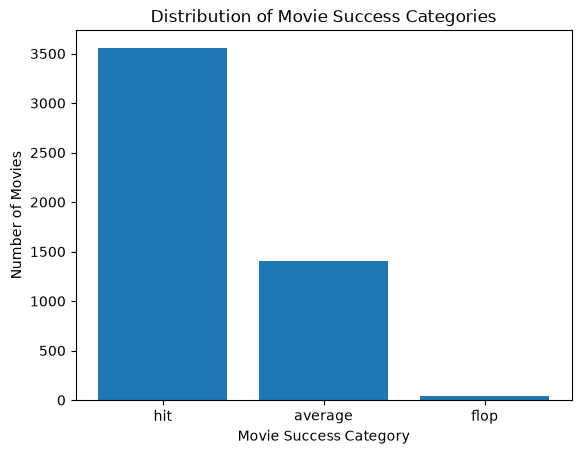

In [56]:
class_counts = df["classify"].value_counts()

plt.bar(class_counts.index, class_counts.values)

plt.title("Distribution of Movie Success Categories")
plt.xlabel("Movie Success Category")
plt.ylabel("Number of Movies")

plt.show()

Exploratory Data Analysis (EDA)

Univariate Analysis:
Univariate analysis is used to study individual features independently and understand their distribution and characteristics.


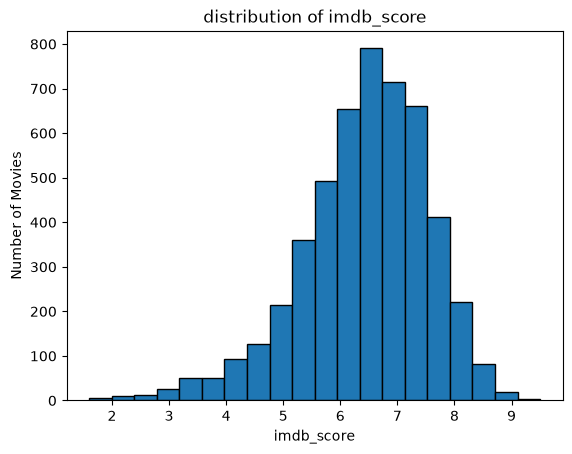

In [57]:
#Distribution of IMDb Scores:
plt.hist(df["imdb_score"], bins=20, edgecolor="black")
plt.title("distribution of imdb_score")
plt.xlabel("imdb_score")
plt.ylabel("Number of Movies")

plt.show()

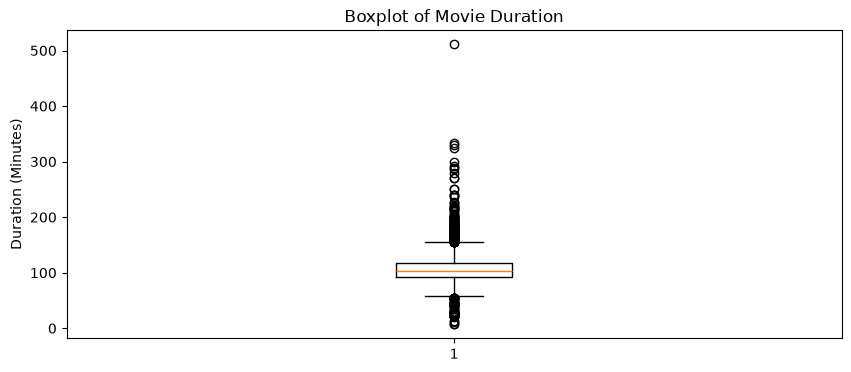

In [58]:
#Distribution of Movie Duration
plt.figure(figsize=(10, 4))
plt.boxplot(df["duration"])
plt.title("Boxplot of Movie Duration")
plt.ylabel("Duration (Minutes)")
plt.show()

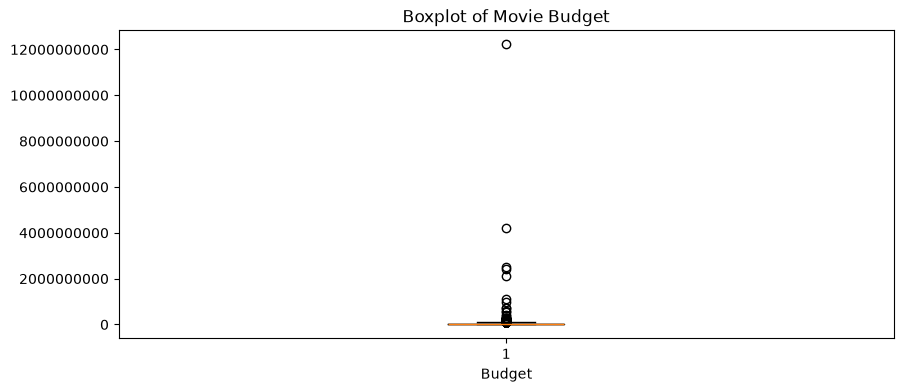

In [59]:
#distribution of movie budget
plt.figure(figsize=(10, 4))
plt.boxplot(df["budget"])
plt.title("Boxplot of Movie Budget")
plt.xlabel("Budget")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

Bivariate Analysis:
Bivariate analysis is performed to examine the relationship between two variables and understand how different movie attributes are associated with movie success.

In [60]:
#Movie Budget vs Movie Success:
#Movie budgets are compared across Hit, Average, and Flop categories to examine whether budget levels differ among movie success categories

hit_budget = df[df["classify"] == "hit"]["budget_original"].dropna()
average_budget = df[df["classify"] == "average"]["budget_original"].dropna()
flop_budget = df[df["classify"] == "flop"]["budget_original"].dropna()  

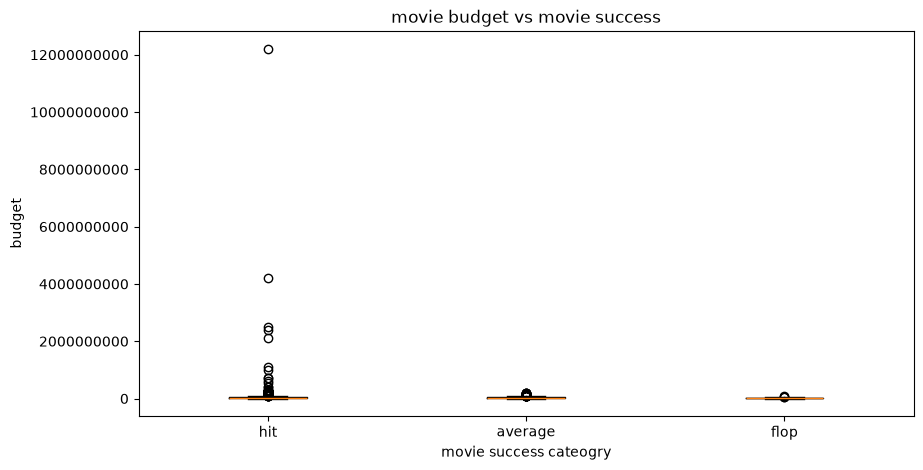

In [61]:
plt.figure(figsize=(10,5))
plt.boxplot([hit_budget,average_budget,flop_budget],tick_labels=["hit","average","flop"])
plt.title("movie budget vs movie success")
plt.xlabel("movie success cateogry")
plt.ylabel("budget")
plt.ticklabel_format(style="plain", axis="y")
plt.show()


In [65]:
# Median Budget by Movie Success Category
df.groupby("classify")["budget_original"].median()

classify
average    20000000.0
flop       19000000.0
hit        19800000.0
Name: budget_original, dtype: float64

**Observation:** I compared the original reported movie budgets across the Hit, Average, and Flop categories. I found that the median budgets are quite similar, at approximately 20 million for Average movies, 19.8 million for Hit movies, and 19 million for Flop movies. This suggests that budget alone does not show a strong difference between the IMDb-based movie success categories. I also observed several very high budget outliers, particularly in the Hit category.

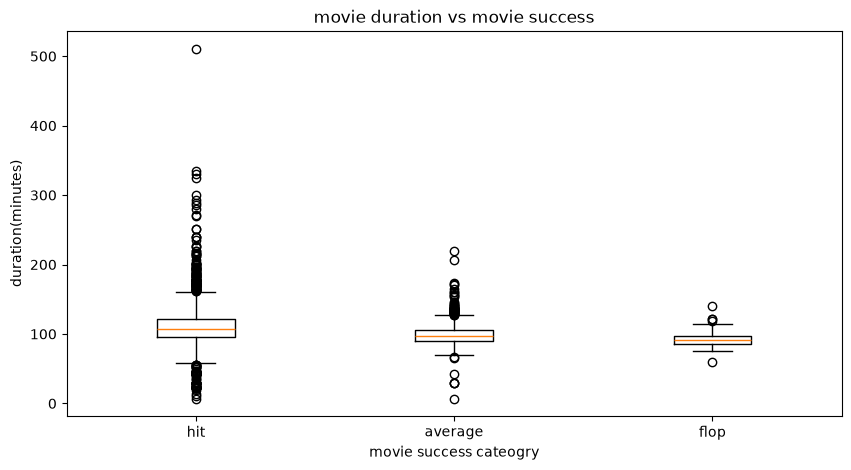

In [103]:
# Movie Duration vs Movie Success:
#Movie duration is compared across Hit, Average, and Flop categories to examine whether movie runtime differs among the success categories.

hit_duration = df[df["classify"] == "hit"]["duration"]
average_duration = df[df["classify"] == "average"]["duration"]
flop_duration = df[df["classify"] == "flop"]["duration"]

plt.figure(figsize=(10,5))
plt.boxplot([hit_duration,average_duration,flop_duration],tick_labels=["hit","average","flop"])
plt.title("movie duration vs movie success")
plt.xlabel("movie success cateogry")
plt.ylabel("duration(minutes)")
plt.show()


In [104]:
#Median duration by Movie Success Category
df.groupby("classify")["duration"].median()

classify
average     97.0
flop        92.0
hit        107.0
Name: duration, dtype: float64

**Observation:** The median duration of Hit movies is 107 minutes, compared with 97 minutes for Average movies and 92 minutes for Flop movies. This indicates that Hit movies in this dataset tend to have a slightly longer typical runtime. The boxplot also shows several duration outliers, particularly in the Hit category.

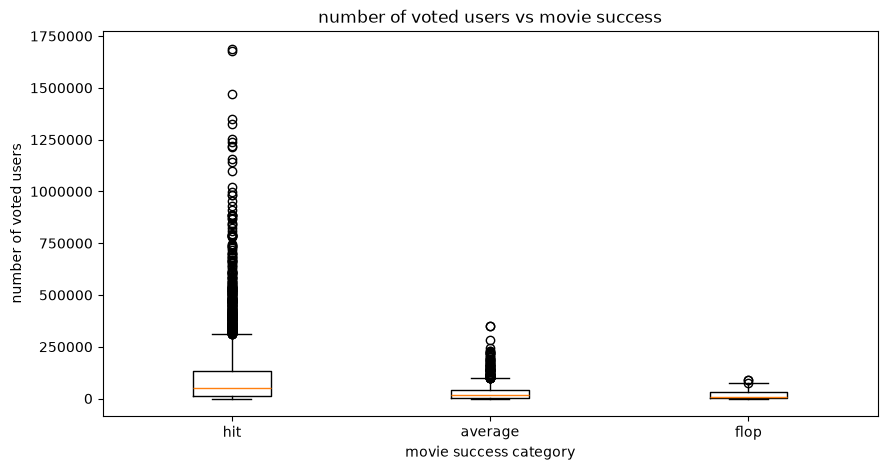

In [105]:
#Number of Voted Users vs Movie Success:
#The number of voted users is compared across Hit, Average, and Flop movie categories to examine whether audience engagement differs among movie success categories.

hit_votes = df[df["classify"] == "hit"]["num_voted_users"]
average_votes = df[df["classify"] == "average"]["num_voted_users"]
flop_votes = df[df["classify"] == "flop"]["num_voted_users"]

plt.figure(figsize=(10,5))
plt.boxplot([hit_votes,average_votes,flop_votes],tick_labels=["hit","average","flop"])
plt.title("number of voted users vs movie success")
plt.xlabel("movie success category")
plt.ylabel("number of voted users")
plt.ticklabel_format(style="plain", axis = "y")
plt.show()


In [106]:
# Median Number of Voted Users by Movie Success Category
df.groupby("classify")["num_voted_users"].median()

classify
average    16222.0
flop        5579.0
hit        49330.0
Name: num_voted_users, dtype: float64

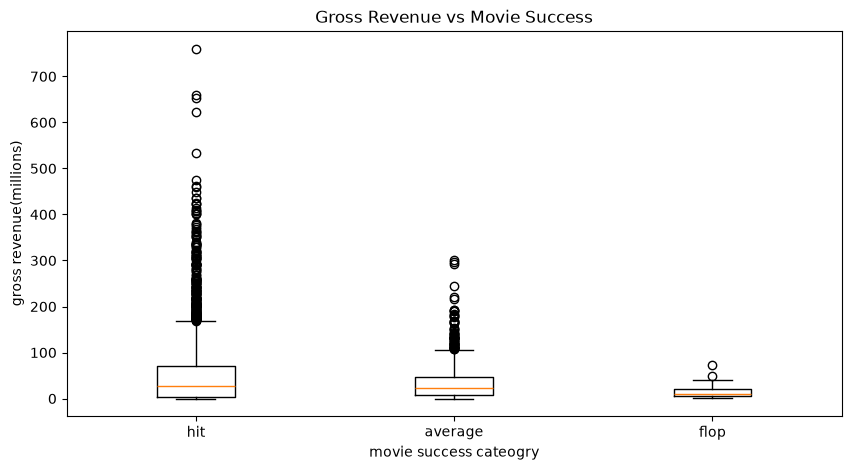

In [66]:
#Gross Revenue vs Movie Success:
#Gross revenue is compared across Hit, Average, and Flop movie categories to examine whether financial performance differs among the IMDb-based movie success categories.
hit_gross = df[df["classify"] == "hit"]["gross_original"].dropna() / 1000000
average_gross = df[df["classify"] == "average"]["gross_original"].dropna() / 1000000
flop_gross = df[df["classify"] == "flop"]["gross_original"].dropna() / 1000000

plt.figure(figsize=(10,5))
plt.boxplot([hit_gross,average_gross,flop_gross],tick_labels=["hit","average","flop"])
plt.title("Gross Revenue vs Movie Success")
plt.xlabel("movie success cateogry")
plt.ylabel("gross revenue(millions)")
plt.ticklabel_format(style="plain", axis = "y")
plt.show()


In [67]:
# Median Gross Revenue by Movie Success category
df.groupby("classify")["gross_original"].median()

classify
average    22134531.0
flop        9109322.0
hit        27296514.0
Name: gross_original, dtype: float64

**Observation:** I compared the original reported gross revenue across the Hit, Average, and Flop categories. I found that Hit movies have the highest median gross revenue at approximately $27.3 million, followed by Average movies at $22.1 million, while Flop movies have a much lower median gross revenue of approximately $9.1 million. This suggests that higher IMDb-rated movie categories in this dataset are generally associated with higher gross revenue. I also observed several high-revenue outliers, particularly among Hit movies.

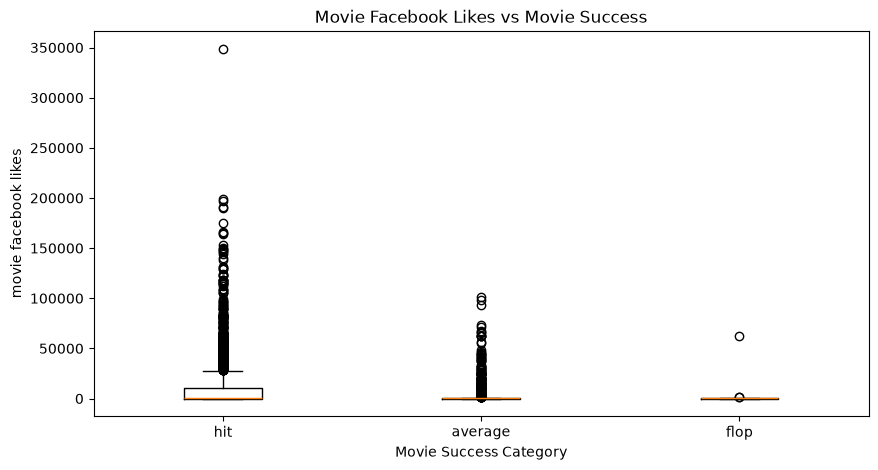

In [109]:
#Movie Facebook Likes vs Movie Success
#Movie Facebook likes are compared across Hit, Average, and Flop movie categories to examine whether social media engagement differs among movie success categories.

hit_likes = df[df["classify"] == "hit"]["movie_facebook_likes"]
average_likes = df[df["classify"] == "average"]["movie_facebook_likes"]
flop_likes = df[df["classify"] == "flop"]["movie_facebook_likes"]

plt.figure(figsize=(10,5))
plt.boxplot([hit_likes,average_likes,flop_likes],tick_labels=["hit","average","flop"])
plt.title("Movie Facebook Likes vs Movie Success")
plt.xlabel("Movie Success Category")
plt.ylabel("movie facebook likes")
plt.show()

In [110]:
# Median Movie Facebook Likes by Movie Success Category
df.groupby("classify")["movie_facebook_likes"].median()

classify
average    207.0
flop       150.0
hit        126.0
Name: movie_facebook_likes, dtype: float64

**Observation:** The median number of movie Facebook likes is 207 for Average movies, 150 for Flop movies, and 126 for Hit movies. Although Hit movies contain several very high Facebook-like outliers, their median is lower than the other categories. This suggests that movie Facebook likes alone do not clearly differentiate the movie success categories in this dataset.

EDA Summary and Key Insights:

The exploratory data analysis helped identify important patterns, distributions, outliers, and relationships within the movie dataset.

# Key Insights

- IMDb scores are mostly concentrated between 5 and 8, with the highest concentration around 6 to 7.
- The target variable is highly imbalanced, with significantly more Hit movies than Average and Flop movies.
- Movie duration contains several outliers, with Hit movies having a higher median duration than Average and Flop movies.
- Median budget does not clearly differentiate the movie success categories.
- Hit movies have a substantially higher median number of IMDb votes compared with Average and Flop movies.
- Median gross revenue does not clearly differentiate the success categories after preprocessing, although Hit movies show several high-revenue outliers.
- Movie Facebook likes contain several extreme values but do not clearly separate the success categories based on median values.
- Some features contain significant outliers and skewed distributions, which should be considered during model preparation.

In [111]:
df.to_csv("cleaned_movie_data.csv", index=False)

In [112]:
df.isnull().sum().sum()

np.int64(0)

In [113]:
print("actor_1_facebook_likes" in df.columns)

True


In [114]:
df.shape

(4998, 28)

In [115]:
df.to_csv("cleaned_movie_data.csv", index=False)

In [116]:
check_df = pd.read_csv("cleaned_movie_data.csv")

print(check_df.shape)
print("actor_1_facebook_likes" in check_df.columns)
print(check_df.isnull().sum().sum())

(4998, 28)
True
0
